BITCOIN KURS ZEITREIHENANALYSE 2016-2026
ARIMA MODELL

 Zeitraum: 2016-01-01 bis 2026-05-03
 Anzahl Tage: 3776
 Bitcoin-Kurs Bereich: $364.33 - $124,752.53
 Schlusskurs (aktuell): $78,538.23

EXPLORATIVE DATENANALYSE

 Deskriptive Statistik:
--------------------------------------------------
  Mittelwert:  $      31,757.78
  Std.Abweichung: $      32,606.47
  Minimum:     $         364.33
  25% Quantil: $       6,519.08
  Median:      $      19,215.43
  75% Quantil: $      50,745.10
  Maximum:     $     124,752.53

 Rendite-Statistik (täglich):
--------------------------------------------------
  Mittlere Rendite:        0.1992%
  Std. Rendite:            3.4946%
  Maximale Rendite:       25.2472%
  Minimale Rendite:      -37.1695%
  Gesamtrendite:         17982.45%


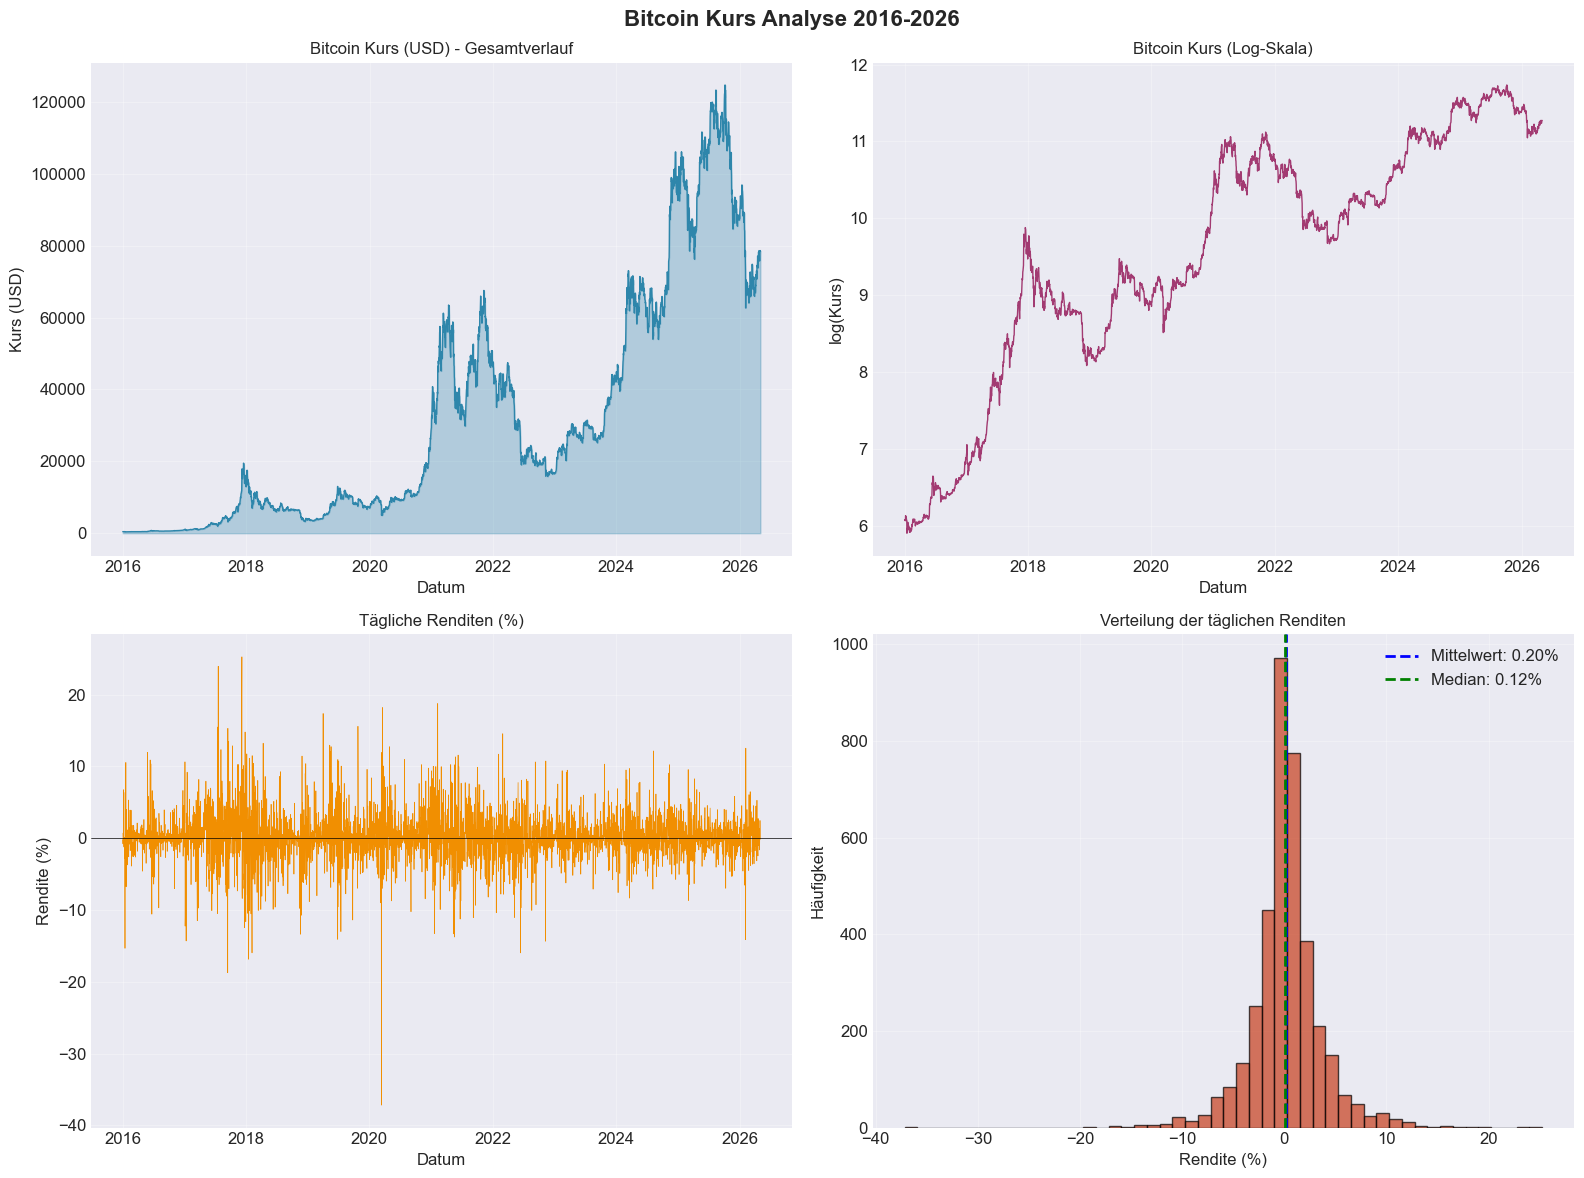


ZERLEGUNG DER ZEITREIHE


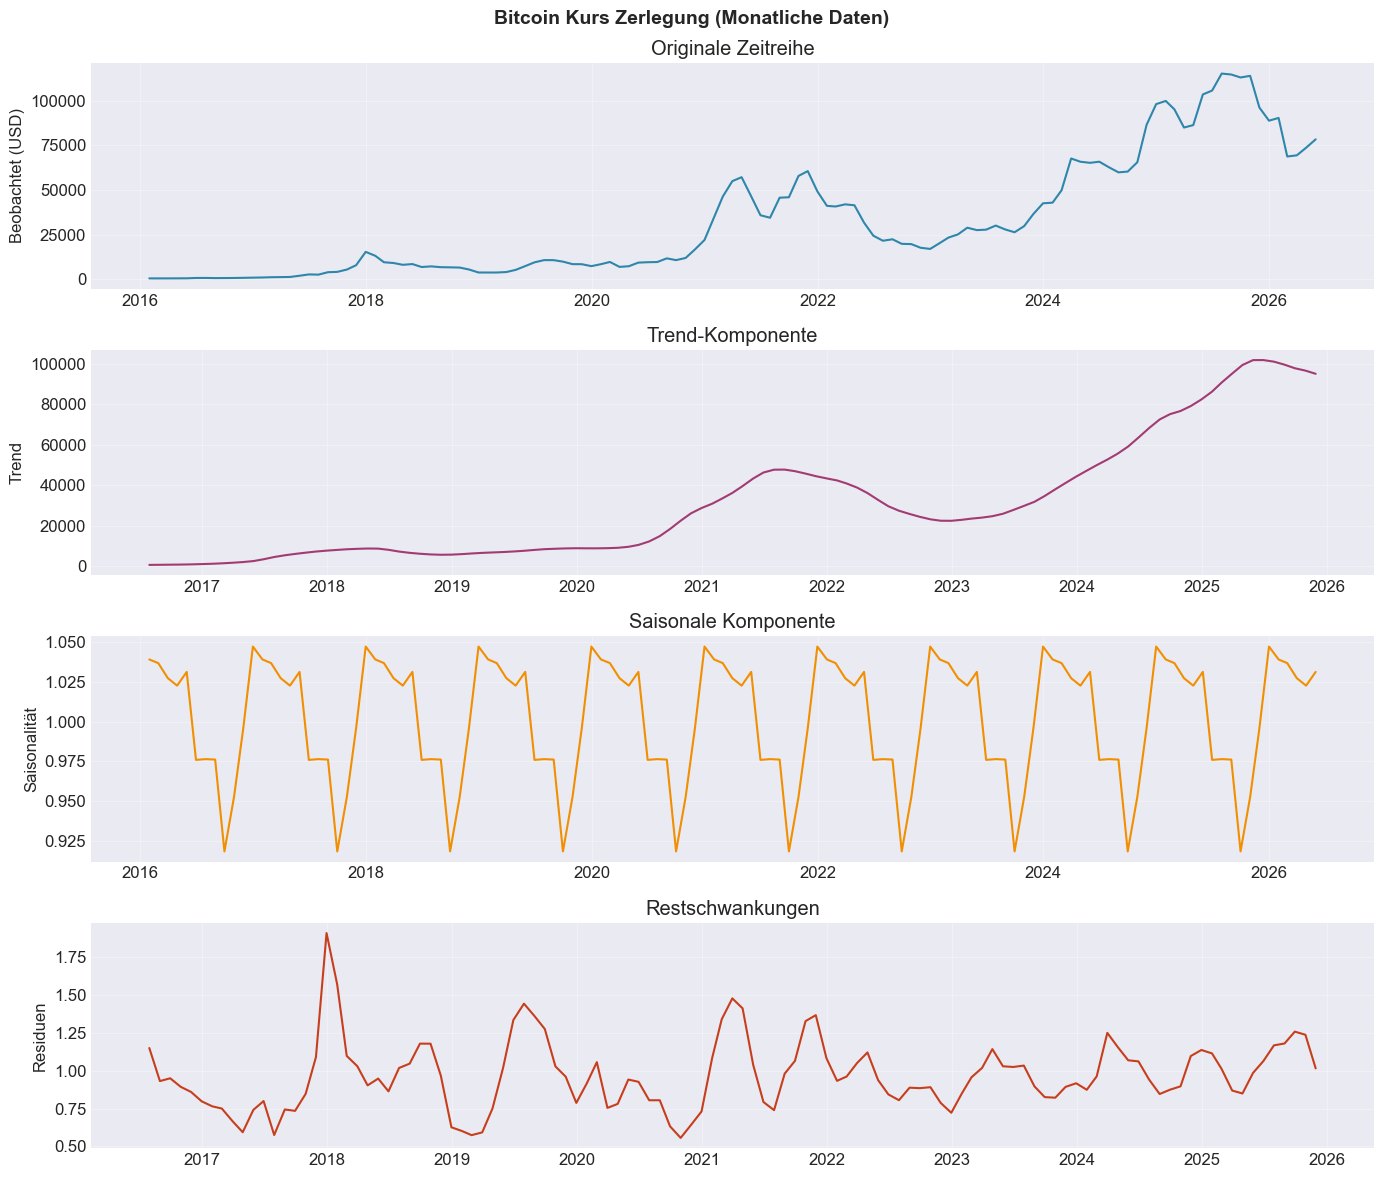


STATIONARITÄTSTESTS (ADF)

 Stationaritätstests:

 ADF Test (Original):
  Statistik               -0.978719
  p-value                  0.760947
  Kritische Werte:    
    1%:  -3.432095
    5%:  -2.862311
    10%:  -2.567180

  → Nicht stationär

 ADF Test (1. Differenz):
  Statistik               -9.384478
  p-value                  0.000000
  Kritische Werte:    
    1%:  -3.432098
    5%:  -2.862312
    10%:  -2.567181

  → Stationär

 ADF Test (log-1. Differenz):
  Statistik              -42.782356
  p-value                  0.000000
  Kritische Werte:    
    1%:  -3.432084
    5%:  -2.862306
    10%:  -2.567178

  → Stationär


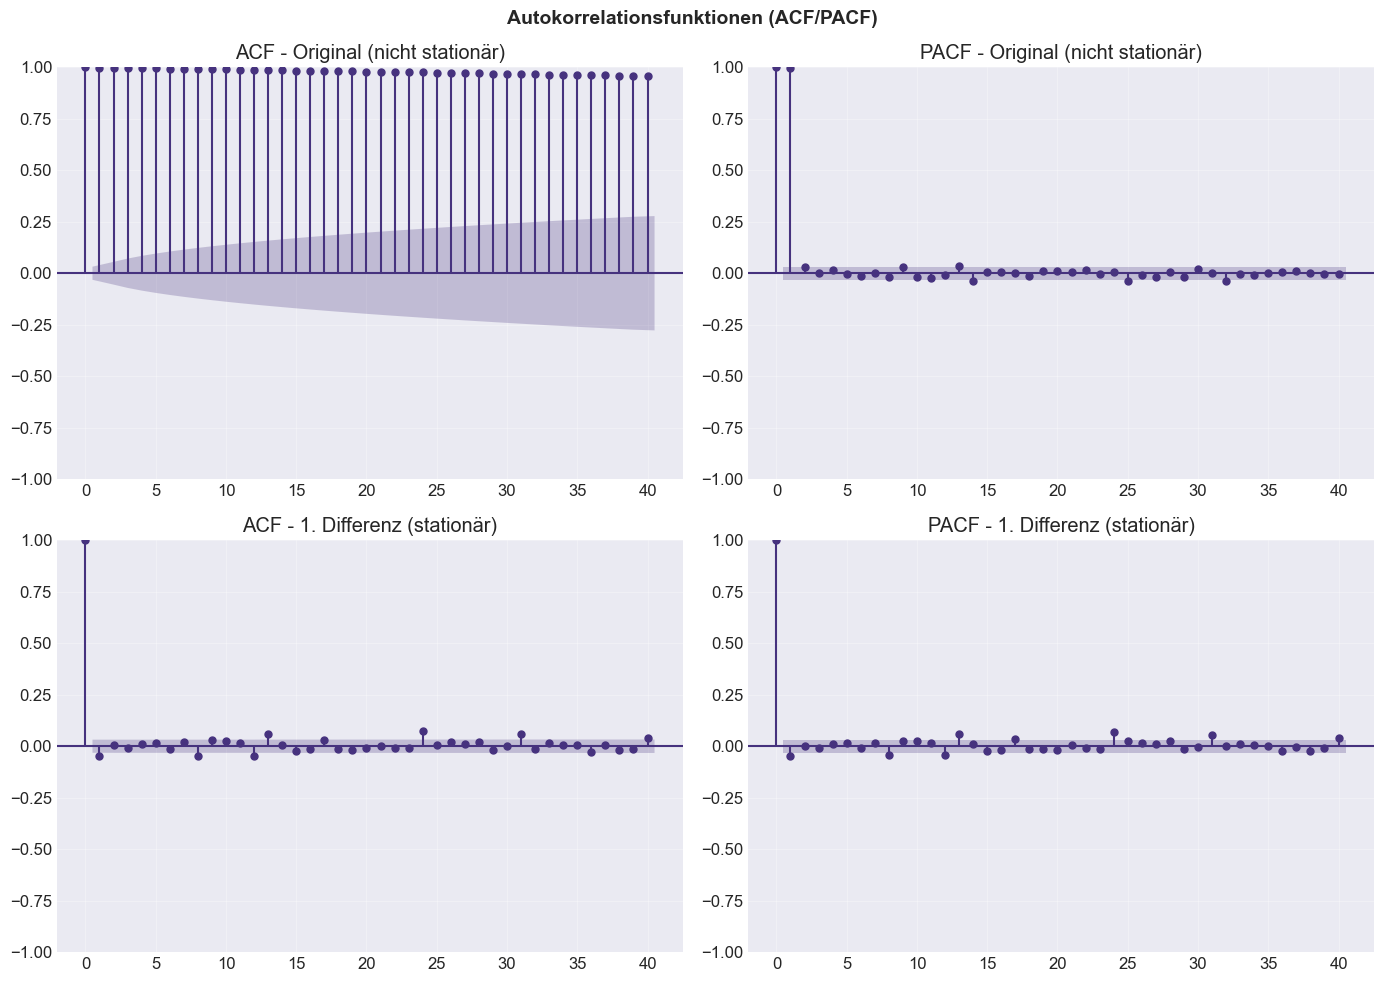


ARIMA MODELLIERUNG (AIC-optimiert)

 Trainingsdaten: 2016-01-01 bis 2026-03-04
 Testdaten: 2026-03-05 bis 2026-05-03

 Suche nach optimalem ARIMA-Modell (p,q mit d=1)...

 Bestes ARIMA-Modell: ARIMA(3, 1, 2)
   AIC: 63243.57

ARIMA MODELL DETAILS
                               SARIMAX Results                                
Dep. Variable:       Bitcoin_Kurs_USD   No. Observations:                 3716
Model:                 ARIMA(3, 1, 2)   Log Likelihood              -31615.786
Date:                Sun, 17 May 2026   AIC                          63243.572
Time:                        20:54:27   BIC                          63280.892
Sample:                    01-01-2016   HQIC                         63256.851
                         - 03-04-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

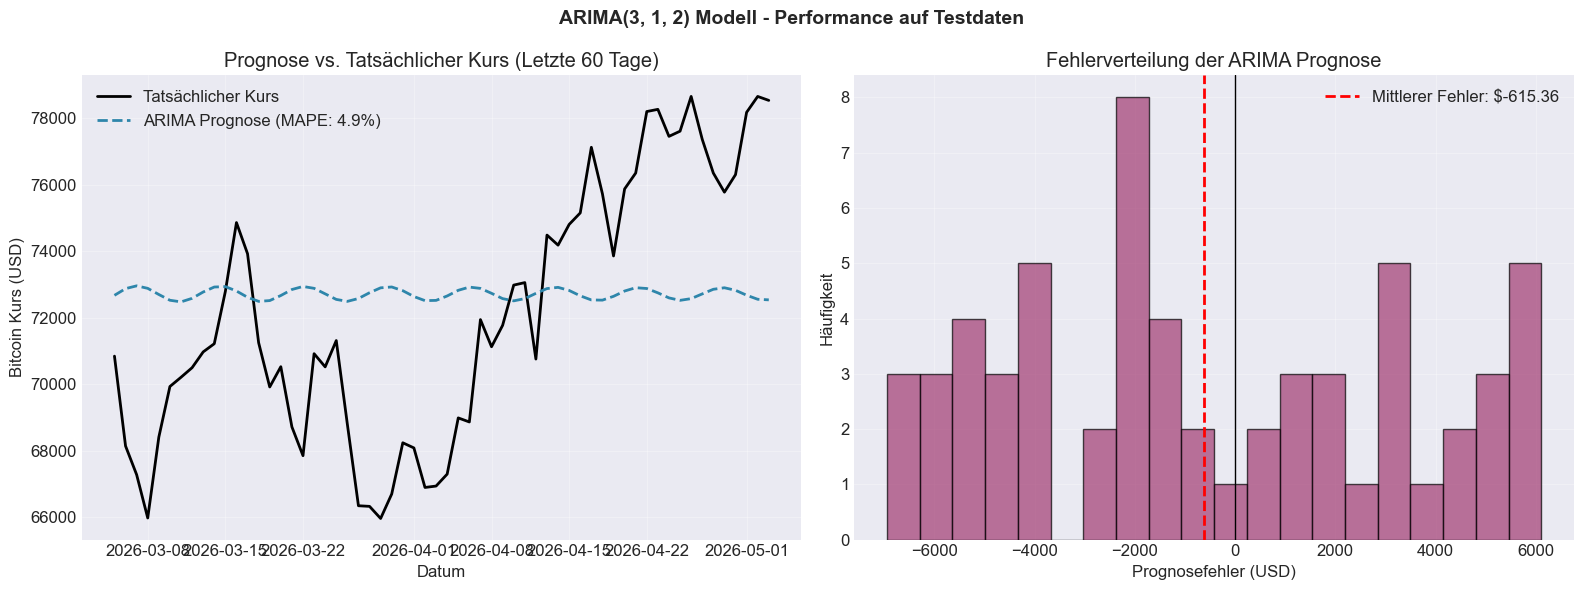

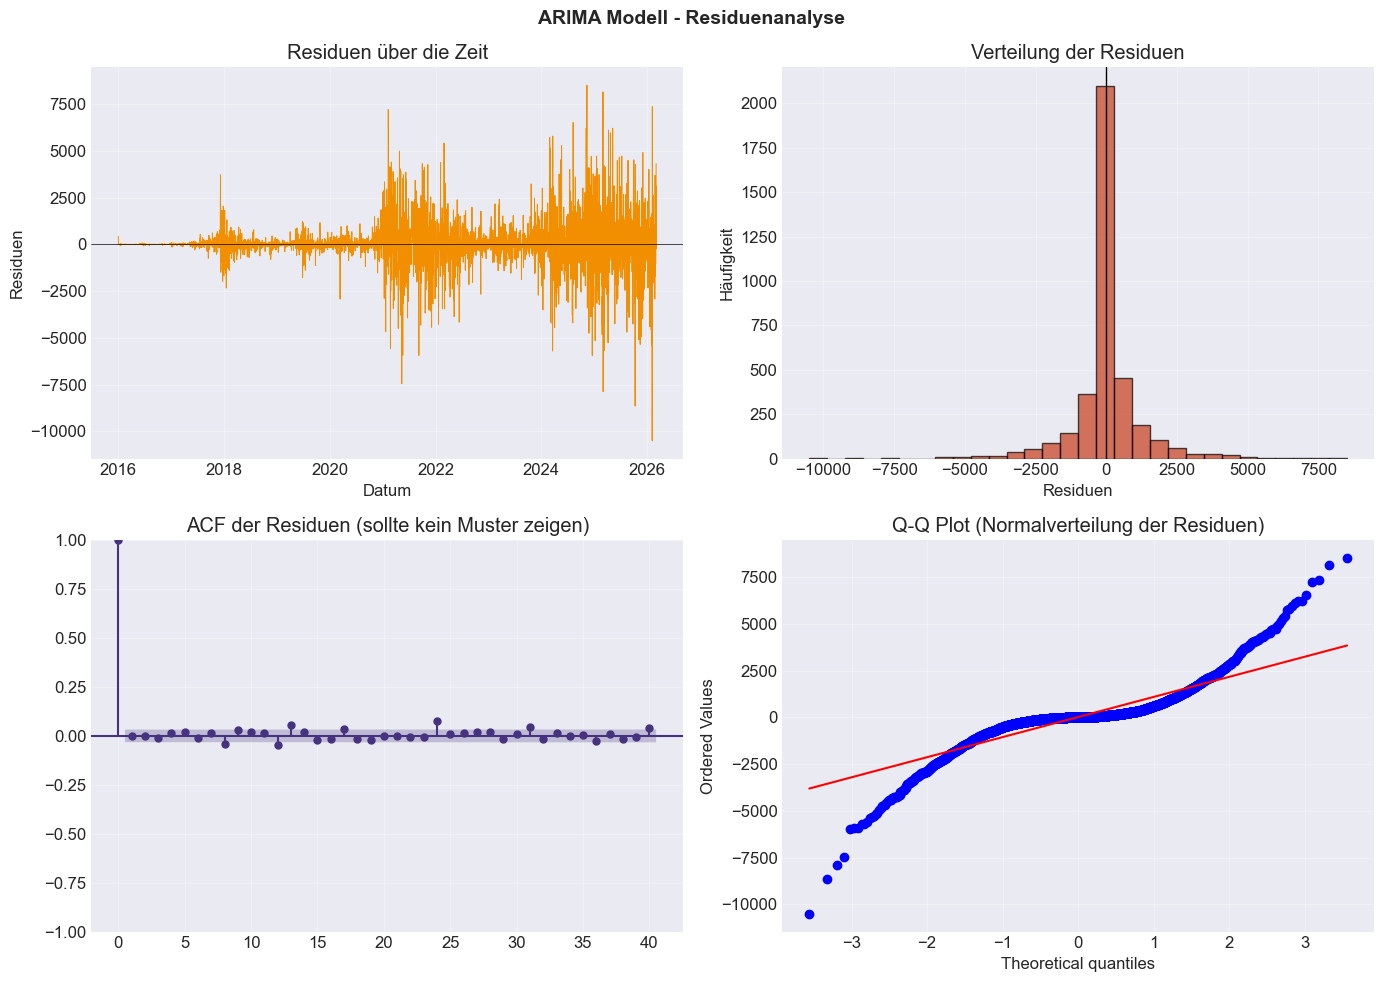


FINALES ARIMA MODELL (Gesamtdaten)

 Finales ARIMA Modell Summary:
                               SARIMAX Results                                
Dep. Variable:       Bitcoin_Kurs_USD   No. Observations:                 3776
Model:                 ARIMA(3, 1, 2)   Log Likelihood              -32143.775
Date:                Sun, 17 May 2026   AIC                          64299.551
Time:                        20:54:28   BIC                          64336.968
Sample:                    01-01-2016   HQIC                         64312.853
                         - 05-03-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2649      0.009     29.883      0.000       0.248       0.282
ar.L2         -0.9845      0.003   -330.169      0.000      -0.

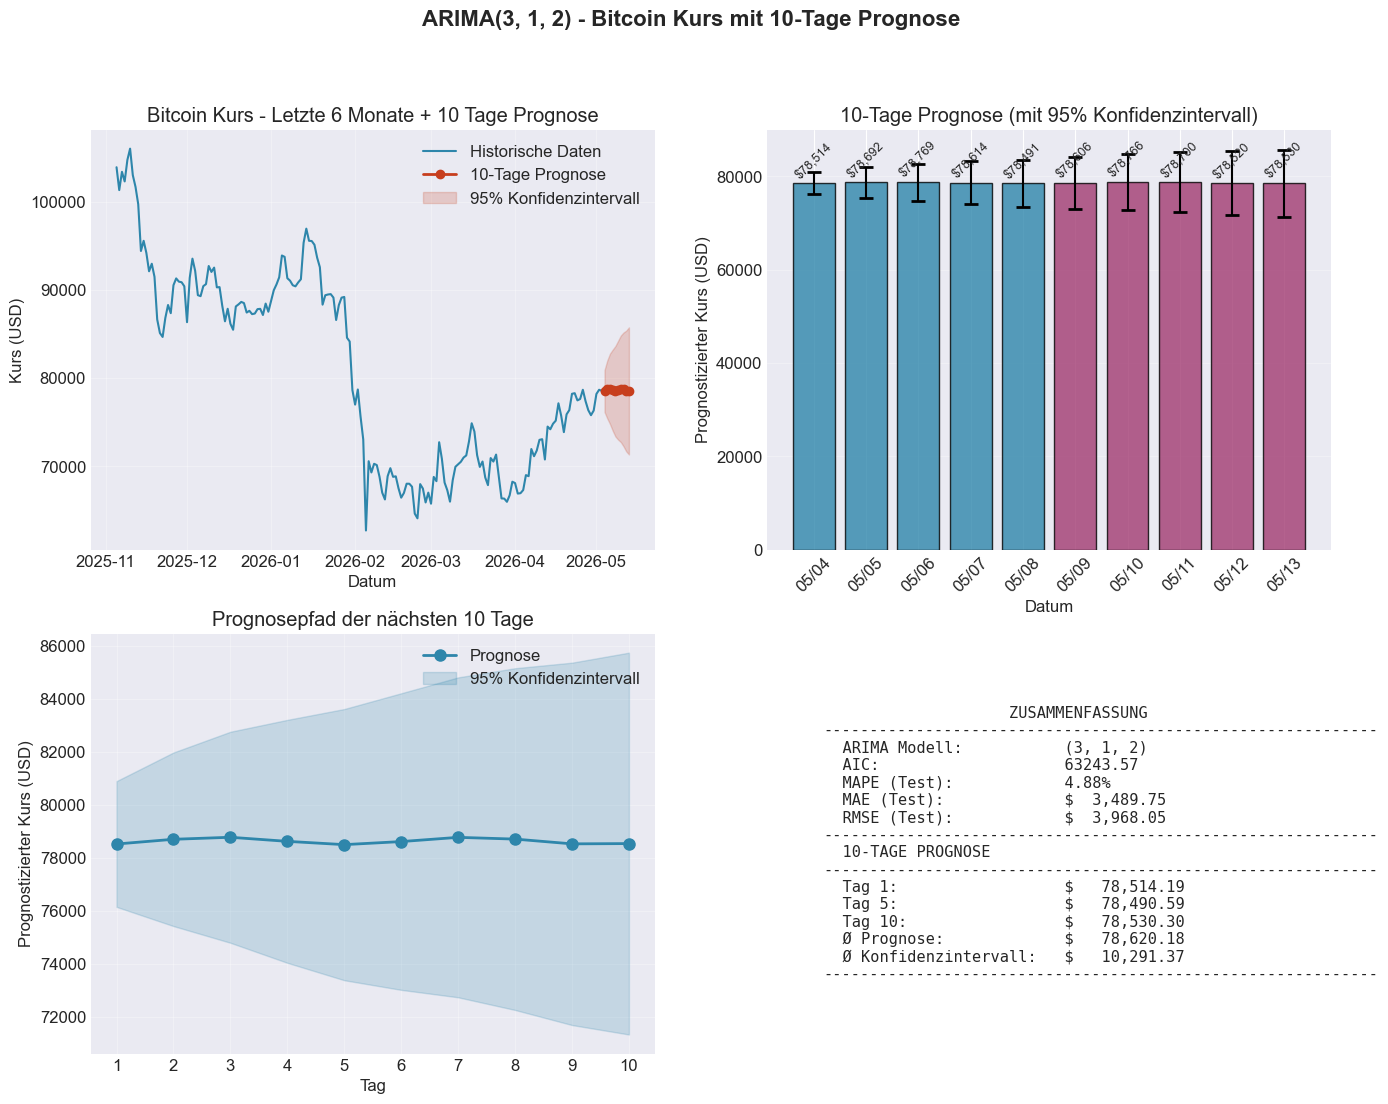

In [3]:
# %% [markdown]
# # Bitcoin Kurs Zeitreihenanalyse (2016-2026)
# ## ARIMA Modell - Einzige Methode

# %% [markdown]
# ### 1. Bibliotheken importieren

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')  # <-- ALLE Warnungen unterdrücken

# Statistische Modelle
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Für Q-Q Plot
from scipy import stats

# Plot Stil
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Grafiken direkt im Notebook anzeigen
%matplotlib inline

# %% [markdown]
# ### 2. Daten laden und vorbereiten

# %%
print("="*70)
print("BITCOIN KURS ZEITREIHENANALYSE 2016-2026")
print("ARIMA MODELL - EINZIGE METHODE")
print("="*70)

# Daten einlesen
df = pd.read_csv('/Users/dg777/Desktop/Zeitreihe_Menden/raw/bitcoin_kurs_2016_2026.csv', skiprows=1)
df.columns = ['Datum', 'Bitcoin_Kurs_USD']
df = df.dropna()

# Datum konvertieren und als Index setzen mit Frequenz
df['Datum'] = pd.to_datetime(df['Datum'])
df = df.set_index('Datum')
df = df.sort_index()

# Frequenz explizit setzen (täglich) - das verhindert die Frequency-Warnung
df = df.asfreq('D')

print(f"\n Zeitraum: {df.index.min().date()} bis {df.index.max().date()}")
print(f" Anzahl Tage: {len(df)}")
print(f" Bitcoin-Kurs Bereich: ${df['Bitcoin_Kurs_USD'].min():,.2f} - ${df['Bitcoin_Kurs_USD'].max():,.2f}")
print(f" Schlusskurs (aktuell): ${df['Bitcoin_Kurs_USD'].iloc[-1]:,.2f}")

# %% [markdown]
# ### 3. Explorative Datenanalyse (EDA)

# %%
print("\n" + "="*70)
print("EXPLORATIVE DATENANALYSE")
print("="*70)

# Statistische Kennzahlen
print("\n Deskriptive Statistik:")
print("-" * 50)
stats_desc = df['Bitcoin_Kurs_USD'].describe()
print(f"  Mittelwert:  ${stats_desc['mean']:>15,.2f}")
print(f"  Std.Abweichung: ${stats_desc['std']:>15,.2f}")
print(f"  Minimum:     ${stats_desc['min']:>15,.2f}")
print(f"  25% Quantil: ${stats_desc['25%']:>15,.2f}")
print(f"  Median:      ${stats_desc['50%']:>15,.2f}")
print(f"  75% Quantil: ${stats_desc['75%']:>15,.2f}")
print(f"  Maximum:     ${stats_desc['max']:>15,.2f}")

# Renditen berechnen
returns = df['Bitcoin_Kurs_USD'].pct_change() * 100
print(f"\n Rendite-Statistik (täglich):")
print("-" * 50)
print(f"  Mittlere Rendite:    {returns.mean():>10.4f}%")
print(f"  Std. Rendite:        {returns.std():>10.4f}%")
print(f"  Maximale Rendite:    {returns.max():>10.4f}%")
print(f"  Minimale Rendite:    {returns.min():>10.4f}%")
print(f"  Gesamtrendite:       {((df['Bitcoin_Kurs_USD'].iloc[-1] / df['Bitcoin_Kurs_USD'].iloc[0]) - 1) * 100:>10.2f}%")

# %% [markdown]
# #### Visualisierung 1: Gesamtverlauf

# %%
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bitcoin Kurs Analyse 2016-2026', fontsize=16, fontweight='bold')

# Hauptzeitreihe
ax1 = axes[0, 0]
ax1.plot(df.index, df['Bitcoin_Kurs_USD'], linewidth=1, color='#2E86AB')
ax1.fill_between(df.index, df['Bitcoin_Kurs_USD'], alpha=0.3, color='#2E86AB')
ax1.set_title('Bitcoin Kurs (USD) - Gesamtverlauf', fontsize=12)
ax1.set_ylabel('Kurs (USD)')
ax1.set_xlabel('Datum')
ax1.grid(True, alpha=0.3)

# Log-Skala
ax2 = axes[0, 1]
ax2.plot(df.index, np.log1p(df['Bitcoin_Kurs_USD']), linewidth=1, color='#A23B72')
ax2.set_title('Bitcoin Kurs (Log-Skala)', fontsize=12)
ax2.set_ylabel('log(Kurs)')
ax2.set_xlabel('Datum')
ax2.grid(True, alpha=0.3)

# Renditen
ax3 = axes[1, 0]
ax3.plot(returns.index, returns, linewidth=0.5, color='#F18F01')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('Tägliche Renditen (%)', fontsize=12)
ax3.set_ylabel('Rendite (%)')
ax3.set_xlabel('Datum')
ax3.grid(True, alpha=0.3)

# Histogramm der Renditen
ax4 = axes[1, 1]
ax4.hist(returns.dropna(), bins=50, color='#C73E1D', edgecolor='black', alpha=0.7)
ax4.axvline(x=returns.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mittelwert: {returns.mean():.2f}%')
ax4.axvline(x=returns.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {returns.median():.2f}%')
ax4.set_title('Verteilung der täglichen Renditen', fontsize=12)
ax4.set_xlabel('Rendite (%)')
ax4.set_ylabel('Häufigkeit')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4. Zerlegung der Zeitreihe

# %%
print("\n" + "="*70)
print("ZERLEGUNG DER ZEITREIHE")
print("="*70)

# Monatliches Resampling (NaN-Werte entfernen für Zerlegung)
df_monthly = df.resample('M').mean().dropna()

# Multiplikative Zerlegung
decomposition = seasonal_decompose(df_monthly['Bitcoin_Kurs_USD'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Bitcoin Kurs Zerlegung (Monatliche Daten)', fontsize=14, fontweight='bold')

axes[0].plot(decomposition.observed, color='#2E86AB')
axes[0].set_ylabel('Beobachtet (USD)')
axes[0].set_title('Originale Zeitreihe')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend, color='#A23B72')
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend-Komponente')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal, color='#F18F01')
axes[2].set_ylabel('Saisonalität')
axes[2].set_title('Saisonale Komponente')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid, color='#C73E1D')
axes[3].set_ylabel('Residuen')
axes[3].set_title('Restschwankungen')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 5. Stationaritätstests (ADF)

# %%
print("\n" + "="*70)
print("STATIONARITÄTSTESTS (ADF)")
print("="*70)

def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n ADF Test {title}:')
    print(f"  {'Statistik':<20} {result[0]:>12.6f}")
    print(f"  {'p-value':<20} {result[1]:>12.6f}")
    print(f"  {'Kritische Werte:':<20}")
    for key, value in result[4].items():
        print(f"    {key}: {value:>10.6f}")
    print(f"\n  → {'Stationär' if result[1] <= 0.05 else 'Nicht stationär'}")
    return result[1] <= 0.05

# Differenzierte Reihen
df_diff = df['Bitcoin_Kurs_USD'].diff().dropna()
df_log = np.log1p(df['Bitcoin_Kurs_USD'])
df_log_diff = df_log.diff().dropna()

print("\n Stationaritätstests:")
adf_test(df['Bitcoin_Kurs_USD'], '(Original)')
adf_test(df_diff, '(1. Differenz)')
adf_test(df_log_diff, '(log-1. Differenz)')

# %% [markdown]
# ### 6. Auto- und partielle Autokorrelation

# %%
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Autokorrelationsfunktionen (ACF/PACF)', fontsize=14, fontweight='bold')

# ACF Original
plot_acf(df['Bitcoin_Kurs_USD'].dropna(), lags=40, ax=axes[0,0])
axes[0,0].set_title('ACF - Original (nicht stationär)')
axes[0,0].grid(True, alpha=0.3)

# PACF Original
plot_pacf(df['Bitcoin_Kurs_USD'].dropna(), lags=40, ax=axes[0,1], method='ywm')
axes[0,1].set_title('PACF - Original (nicht stationär)')
axes[0,1].grid(True, alpha=0.3)

# ACF Differenziert
plot_acf(df_diff.dropna(), lags=40, ax=axes[1,0])
axes[1,0].set_title('ACF - 1. Differenz (stationär)')
axes[1,0].grid(True, alpha=0.3)

# PACF Differenziert
plot_pacf(df_diff.dropna(), lags=40, ax=axes[1,1], method='ywm')
axes[1,1].set_title('PACF - 1. Differenz (stationär)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 7. ARIMA Modellierung (AIC-optimiert)

# %%
print("\n" + "="*70)
print("ARIMA MODELLIERUNG (AIC-optimiert)")
print("="*70)

# Aufteilen in Trainings- und Testdaten (letzte 60 Tage als Test)
train = df.iloc[:-60]
test = df.iloc[-60:]

print(f"\n Trainingsdaten: {train.index.min().date()} bis {train.index.max().date()}")
print(f" Testdaten: {test.index.min().date()} bis {test.index.max().date()}")

# Automatische Bestimmung der optimalen (p,q) basierend auf AIC
print("\n Suche nach optimalem ARIMA-Modell (p,q mit d=1)...")

best_aic = np.inf
best_order = None
best_model = None

# Reduzierte Suche für bessere Performance (nur p,q bis 3)
p_values = range(0, 4)
q_values = range(0, 4)

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(train['Bitcoin_Kurs_USD'], order=(p, 1, q))
            fitted = model.fit(method_kwargs={'maxiter': 200})  # Mehr Iterationen für Konvergenz
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, 1, q)
                best_model = fitted
        except:
            continue

print(f"\n Bestes ARIMA-Modell: ARIMA{best_order}")
print(f"   AIC: {best_aic:.2f}")

# Detaillierte Modellausgabe
print("\n" + "="*70)
print("ARIMA MODELL DETAILS")
print("="*70)
print(best_model.summary())

# Ljung-Box Test für Residuen
residuals = best_model.resid
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("\n Ljung-Box Test für Residuen (Autokorrelation):")
print(lb_test)

# Prognose für Testzeitraum
forecast_arima = best_model.forecast(steps=len(test))

# Metriken für ARIMA
mae = mean_absolute_error(test['Bitcoin_Kurs_USD'], forecast_arima)
rmse = np.sqrt(mean_squared_error(test['Bitcoin_Kurs_USD'], forecast_arima))
mape = np.mean(np.abs((test['Bitcoin_Kurs_USD'].values - forecast_arima) / test['Bitcoin_Kurs_USD'].values)) * 100

print(f"\n ARIMA Performance auf Testdaten (60 Tage):")
print("-" * 40)
print(f"  MAE:  ${mae:>12,.2f}")
print(f"  RMSE: ${rmse:>12,.2f}")
print(f"  MAPE: {mape:>11.2f}%")

# %% [markdown]
# ### 8. Visualisierung der Modellperformance

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'ARIMA{best_order} Modell - Performance auf Testdaten', fontsize=14, fontweight='bold')

# Vergleich der Prognosen
ax1 = axes[0]
ax1.plot(test.index, test['Bitcoin_Kurs_USD'], label='Tatsächlicher Kurs', color='black', linewidth=2)
ax1.plot(test.index, forecast_arima, label=f'ARIMA Prognose (MAPE: {mape:.1f}%)', color='#2E86AB', linestyle='--', linewidth=2)
ax1.set_title('Prognose vs. Tatsächlicher Kurs (Letzte 60 Tage)')
ax1.set_xlabel('Datum')
ax1.set_ylabel('Bitcoin Kurs (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fehlerverteilung
ax2 = axes[1]
errors = test['Bitcoin_Kurs_USD'].values - forecast_arima
ax2.hist(errors, bins=20, color='#A23B72', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mittlerer Fehler: ${errors.mean():.2f}')
ax2.set_title('Fehlerverteilung der ARIMA Prognose')
ax2.set_xlabel('Prognosefehler (USD)')
ax2.set_ylabel('Häufigkeit')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 9. Residuenanalyse

# %%
residuals_full = best_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ARIMA Modell - Residuenanalyse', fontsize=14, fontweight='bold')

# Residuen über Zeit
axes[0, 0].plot(residuals_full.index, residuals_full, color='#F18F01', linewidth=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].set_title('Residuen über die Zeit')
axes[0, 0].set_xlabel('Datum')
axes[0, 0].set_ylabel('Residuen')
axes[0, 0].grid(True, alpha=0.3)

# Histogramm der Residuen
axes[0, 1].hist(residuals_full, bins=30, color='#C73E1D', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_title('Verteilung der Residuen')
axes[0, 1].set_xlabel('Residuen')
axes[0, 1].set_ylabel('Häufigkeit')
axes[0, 1].grid(True, alpha=0.3)

# ACF der Residuen
plot_acf(residuals_full.dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF der Residuen (sollte kein Muster zeigen)')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(residuals_full.dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalverteilung der Residuen)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 10. Finales ARIMA Modell (Gesamtdaten)

# %%
print("\n" + "="*70)
print("FINALES ARIMA MODELL (Gesamtdaten)")
print("="*70)

# Finales Modell mit allen Daten und optimaler Ordnung
final_model = ARIMA(df['Bitcoin_Kurs_USD'], order=best_order)
final_fitted = final_model.fit(method_kwargs={'maxiter': 200})

print("\n Finales ARIMA Modell Summary:")
print(final_fitted.summary())

# %% [markdown]
# ### 11. 10-Tage Bitcoin Kurs Prognose

# %%
print("\n" + "="*70)
print("10-TAGE BITCOIN KURS PROGNOSE")
print("="*70)

# Forecast für 10 Tage
forecast_result = final_fitted.get_forecast(steps=10)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Detaillierte Tabelle
print("\n 10-Tage Prognose im Detail:")
print("=" * 70)
print(f"{'Nr.':<4} {'Datum':<12} {'Prognose (USD)':<18} {'Untere Grenze':<15} {'Obere Grenze':<15} {'Spannweite':<12}")
print("=" * 70)

forecast_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=10, freq='D')

for i, (date, pred, ci) in enumerate(zip(forecast_dates, forecast_mean, forecast_ci.values), 1):
    span = ci[1] - ci[0]
    print(f"{i:<4} {date.strftime('%Y-%m-%d'):<12} ${pred:>15,.2f} ${ci[0]:>14,.2f} ${ci[1]:>14,.2f} ${span:>11,.2f}")

print("=" * 70)

# Zusätzliche Statistiken zum Forecast
print("\n Forecast-Statistiken:")
print("-" * 40)
print(f"  Durchschnittliche Prognose:  ${forecast_mean.mean():>15,.2f}")
print(f"  Minimale Prognose:          ${forecast_mean.min():>15,.2f}")
print(f"  Maximale Prognose:          ${forecast_mean.max():>15,.2f}")
print(f"  Prognoseänderung (Tag 1-10): ${(forecast_mean.iloc[-1] - forecast_mean.iloc[0]):>+12,.2f}")
print(f"  Durchschnittl. Konfidenzspanne: ${(forecast_ci.values[:, 1] - forecast_ci.values[:, 0]).mean():>11,.2f}")

# %% [markdown]
# ### 12. Visualisierung der 10-Tage Prognose

# %%
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'ARIMA{best_order} - Bitcoin Kurs mit 10-Tage Prognose', fontsize=16, fontweight='bold')

# Gesamtverlauf mit Forecast (letzte 180 Tage)
ax1 = axes[0, 0]
ax1.plot(df.index[-180:], df['Bitcoin_Kurs_USD'][-180:], label='Historische Daten', color='#2E86AB', linewidth=1.5)
ax1.plot(forecast_dates, forecast_mean, label='10-Tage Prognose', color='#C73E1D', linewidth=2, marker='o', markersize=6)
ax1.fill_between(forecast_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                   color='#C73E1D', alpha=0.2, label='95% Konfidenzintervall')
ax1.set_title('Bitcoin Kurs - Letzte 6 Monate + 10 Tage Prognose')
ax1.set_xlabel('Datum')
ax1.set_ylabel('Kurs (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
# 10-Tage Forecast als Balkendiagramm
ax2 = axes[0, 1]
colors = ['#2E86AB' if i < 5 else '#A23B72' for i in range(10)]
bars = ax2.bar(range(1, 11), forecast_mean, color=colors, edgecolor='black', alpha=0.8)
ax2.errorbar(range(1, 11), forecast_mean, 
             yerr=[forecast_mean - forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1] - forecast_mean],
             fmt='none', color='black', capsize=5, capthick=2)
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels([d.strftime('%m/%d') for d in forecast_dates], rotation=45)
ax2.set_title('10-Tage Prognose (mit 95% Konfidenzintervall)')
ax2.set_xlabel('Datum')
ax2.set_ylabel('Prognostizierter Kurs (USD)')
ax2.grid(True, alpha=0.3, axis='y')

# Werte auf Balken
for i, (bar, val) in enumerate(zip(bars, forecast_mean)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9, rotation=45)

# Prognosepfad mit Konfidenzband
ax3 = axes[1, 0]
ax3.plot(range(1, 11), forecast_mean, 'o-', color='#2E86AB', linewidth=2, markersize=8, label='Prognose')
ax3.fill_between(range(1, 11), forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                   color='#2E86AB', alpha=0.2, label='95% Konfidenzintervall')
ax3.set_xticks(range(1, 11))
ax3.set_xlabel('Tag')
ax3.set_ylabel('Prognostizierter Kurs (USD)')
ax3.set_title('Prognosepfad der nächsten 10 Tage')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Zusammenfassung der wichtigsten Kennzahlen
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
                    ZUSAMMENFASSUNG
------------------------------------------------------------
  ARIMA Modell:           {best_order}
  AIC:                    {best_aic:.2f}
  MAPE (Test):            {mape:.2f}%
  MAE (Test):             ${mae:>10,.2f}
  RMSE (Test):            ${rmse:>10,.2f}
------------------------------------------------------------
  10-TAGE PROGNOSE
------------------------------------------------------------
  Tag 1:                  ${forecast_mean.iloc[0]:>12,.2f}
  Tag 5:                  ${forecast_mean.iloc[4]:>12,.2f}
  Tag 10:                 ${forecast_mean.iloc[-1]:>12,.2f}
  Ø Prognose:             ${forecast_mean.mean():>12,.2f}
  Ø Konfidenzintervall:   ${(forecast_ci.iloc[:, 1] - forecast_ci.iloc[:, 0]).mean():>12,.2f}
------------------------------------------------------------
"""
ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes, fontsize=11, 
         verticalalignment='center', fontfamily='monospace')

# %% [markdown]
# ### 13. Zusammenfassung

# %%
print("\n" + "="*70)
print("ANALYSE ABGESCHLOSSEN!")
print("="*70)
print(f"\n Zusammenfassung:")
print(f"   Bestes Modell: ARIMA{best_order}")
print(f"   Test-MAPE: {mape:.2f}%")
print(f"   Prognose Tag 10: ${forecast_mean.iloc[-1]:,.2f}")
print(f"   95% Konfidenzintervall Tag 10: [${forecast_ci.iloc[-1, 0]:,.2f}, ${forecast_ci.iloc[-1, 1]:,.2f}]")